# 03b Model Explainability: Two-Stage SHAP

This notebook explains the two-stage (hurdle) model using SHAP values.

- **Stage 1** classifier: predicts whether a census tract has any solar deployment (`installed = tile_count > 0`)
- **Stage 2** regressor: predicts deployment intensity among installed tracts (`log1p` density)

Both stages are explained separately because they model different phenomena.

Default setting:

```text
PROFILE     = transfer
FEATURE_SET = voted
```

## Setup

In [1]:
import sys
sys.path.append('../')

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import shap
except ImportError as exc:
    raise ImportError(
        "SHAP is not installed. Run `python -m pip install shap` in the active virtual environment, "
        "then restart this notebook kernel."
    ) from exc

RANDOM_STATE  = 42
SAMPLE_SIZE   = 2000
PROFILE       = 'transfer'
FEATURE_SET   = 'voted'

RESULT_DIR    = f'../outputs/results/{PROFILE}'
FIGURE_DIR    = f'../outputs/figures/{PROFILE}'
MODEL_PATH    = f'{RESULT_DIR}/best_us_twostage_model_{FEATURE_SET}.pkl'
RAW_DATA_PATH = '../deepsolar_tract.csv'   # source of tile_count / household_count

os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

## Load Model and Data

In [2]:
with open(MODEL_PATH, 'rb') as f:
    bundle = pickle.load(f)

classifier    = bundle['classifier']
regressor     = bundle['regressor']
imputer       = bundle['imputer']
feature_names = bundle['feature_names']

# Load raw data — processed CSVs only contain feature columns, not tile_count
raw_df = pd.read_csv(RAW_DATA_PATH, encoding='latin-1')
model_df = raw_df[feature_names + ['tile_count', 'household_count']].copy()
model_df = model_df.dropna(subset=['tile_count'])

y_tile       = model_df['tile_count'].astype(float).values
y_households = model_df['household_count'].fillna(model_df['household_count'].median()).values
y_installed  = (y_tile > 0).astype(int)
y_density    = y_tile / y_households * 1000   # solar systems per 1000 households

X_df = model_df[feature_names].copy()

print(f'Model path  : {MODEL_PATH}')
print(f'Classifier  : {type(classifier).__name__}')
print(f'Regressor   : {type(regressor).__name__}')
print(f'Features    : {len(feature_names)}')
print(f'Data shape  : {X_df.shape}')
print(f'Installed   : {y_installed.sum()} / {len(y_installed)} ({y_installed.mean():.3f})')

Model path  : ../outputs/results/transfer/best_us_twostage_model_voted.pkl
Classifier  : RandomForestClassifier
Regressor   : RandomForestRegressor
Features    : 90
Data shape  : (72537, 90)
Installed   : 56258 / 72537 (0.776)


C:\Users\User\AppData\Local\Temp\ipykernel_6068\1478149427.py:17: RuntimeWarning: divide by zero encountered in divide
  y_density    = y_tile / y_households * 1000   # solar systems per 1000 households
C:\Users\User\AppData\Local\Temp\ipykernel_6068\1478149427.py:17: RuntimeWarning: invalid value encountered in divide
  y_density    = y_tile / y_households * 1000   # solar systems per 1000 households


## Impute and Split

In [3]:
X_imp = imputer.transform(X_df.values)
X_imp_df = pd.DataFrame(X_imp, columns=feature_names)

# Stage 2: only rows with installation
pos_mask = y_installed == 1
X_pos_df = X_imp_df[pos_mask].copy()

print(f'All rows    : {X_imp_df.shape[0]}')
print(f'Installed   : {X_pos_df.shape[0]}')

All rows    : 72537
Installed   : 56258


## Sample Data for SHAP

In [4]:
rng = np.random.default_rng(RANDOM_STATE)

# Stage 1 sample: all rows
n1 = min(SAMPLE_SIZE, len(X_imp_df))
idx1 = rng.choice(len(X_imp_df), size=n1, replace=False)
X_shap1 = X_imp_df.iloc[idx1].copy()

# Stage 2 sample: installed rows only
n2 = min(SAMPLE_SIZE, len(X_pos_df))
idx2 = rng.choice(len(X_pos_df), size=n2, replace=False)
X_shap2 = X_pos_df.iloc[idx2].copy()

print(f'Stage 1 SHAP sample: {X_shap1.shape}')
print(f'Stage 2 SHAP sample: {X_shap2.shape}')

Stage 1 SHAP sample: (2000, 90)
Stage 2 SHAP sample: (2000, 90)


## Stage 1 SHAP: Has Solar Deployment?

In [5]:
explainer1 = shap.TreeExplainer(classifier)
shap_raw1  = explainer1.shap_values(X_shap1)

# For binary classifiers, shap_values may return [neg_class, pos_class] or a 3-D array
if isinstance(shap_raw1, list):
    # list of 2 arrays → use class-1 (installed) for interpretation
    shap_vals1 = shap_raw1[1]
elif isinstance(shap_raw1, np.ndarray) and shap_raw1.ndim == 3:
    shap_vals1 = shap_raw1[:, :, 1]
else:
    # single 2-D array (some tree models)
    shap_vals1 = shap_raw1

print(f'Stage 1 SHAP array shape: {shap_vals1.shape}')

Stage 1 SHAP array shape: (2000, 90)


### Stage 1 Global Importance

In [6]:
mean_abs1 = np.abs(shap_vals1).mean(axis=0)
stage1_importance = pd.DataFrame({'feature': feature_names, 'mean_abs_shap': mean_abs1})
stage1_importance = stage1_importance.sort_values('mean_abs_shap', ascending=False)

save_path = f'{RESULT_DIR}/03b_shap_stage1_importance_{FEATURE_SET}.csv'
stage1_importance.to_csv(save_path, index=False)

print(f'Saved to {save_path}')
print(stage1_importance.head(15).to_string(index=False))

Saved to ../outputs/results/transfer/03b_shap_stage1_importance_voted.csv
                       feature  mean_abs_shap
                    total_area       0.035620
            population_density       0.035534
            education_bachelor       0.026777
                    population       0.021142
   heating_fuel_coal_coke_rate       0.019796
         daily_solar_radiation       0.019124
     housing_unit_median_value       0.014156
             education_college       0.012940
             relative_humidity       0.012154
     electricity_consume_total       0.012043
  electricity_price_industrial       0.011667
 education_professional_school       0.010479
housing_unit_median_gross_rent       0.010293
              heating_fuel_gas       0.009905
         occupancy_vacant_rate       0.008908


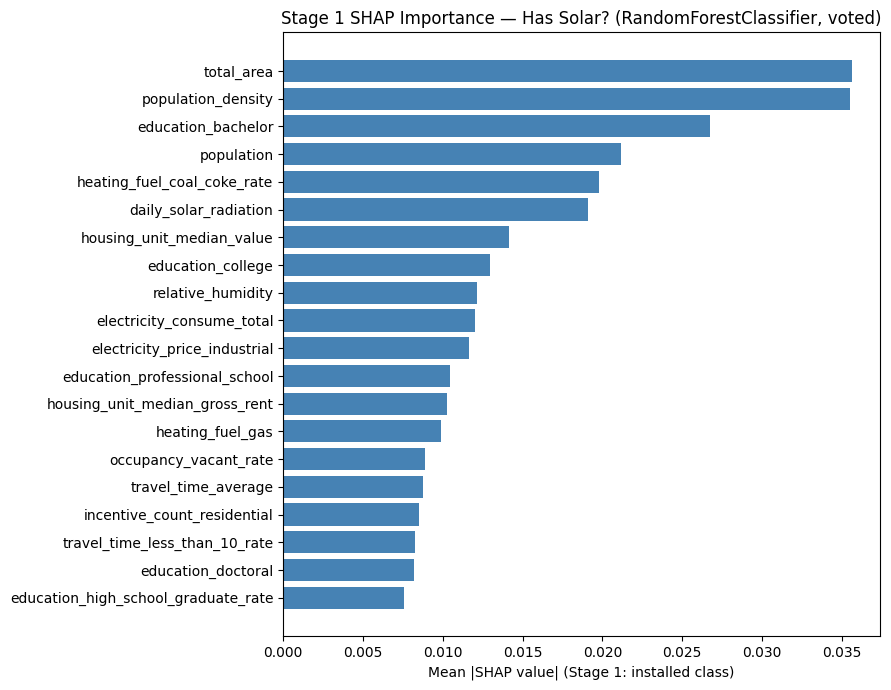

Saved to ../outputs/figures/transfer/03b_shap_stage1_bar_voted.png


In [7]:
top1 = stage1_importance.head(20).sort_values('mean_abs_shap')

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top1['feature'], top1['mean_abs_shap'], color='steelblue')
ax.set_xlabel('Mean |SHAP value| (Stage 1: installed class)')
ax.set_title(f'Stage 1 SHAP Importance — Has Solar? ({type(classifier).__name__}, {FEATURE_SET})')
plt.tight_layout()
fig_path = f'{FIGURE_DIR}/03b_shap_stage1_bar_{FEATURE_SET}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved to {fig_path}')

### Stage 1 SHAP Summary Plot

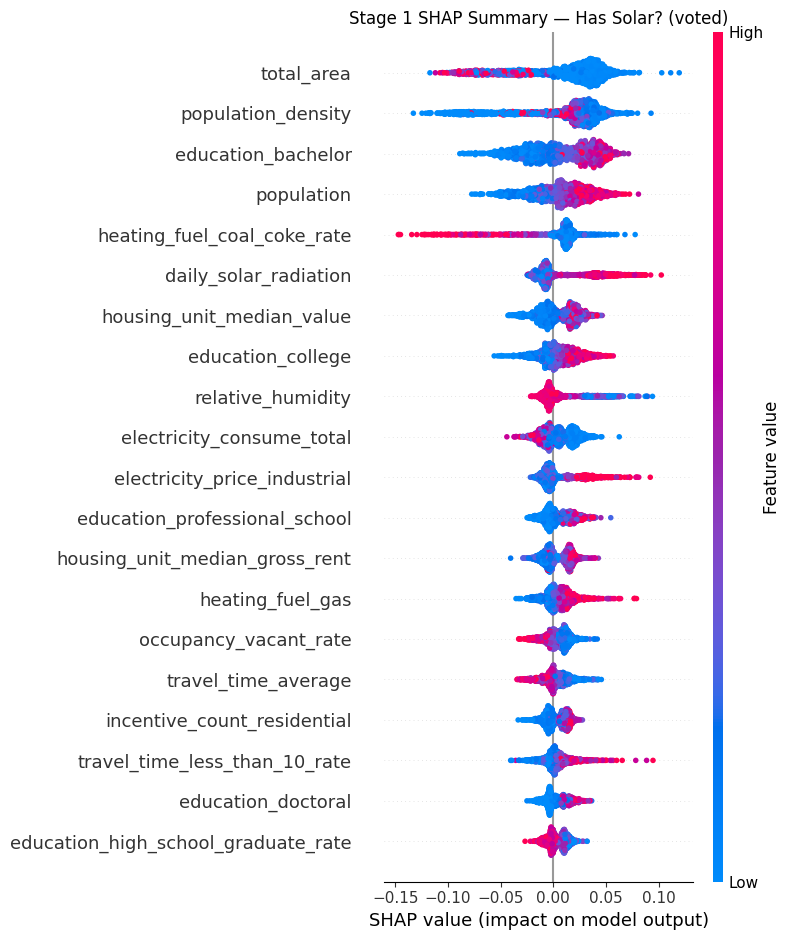

Saved to ../outputs/figures/transfer/03b_shap_stage1_summary_voted.png


In [8]:
plt.figure()
shap.summary_plot(shap_vals1, X_shap1, max_display=20, show=False)
plt.title(f'Stage 1 SHAP Summary — Has Solar? ({FEATURE_SET})')
plt.tight_layout()
fig_path = f'{FIGURE_DIR}/03b_shap_stage1_summary_{FEATURE_SET}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved to {fig_path}')

## Stage 2 SHAP: Deployment Intensity (installed tracts only)

In [9]:
explainer2 = shap.TreeExplainer(regressor)
shap_raw2  = explainer2.shap_values(X_shap2)

# Regression: single 2-D array
if isinstance(shap_raw2, list):
    shap_vals2 = shap_raw2[0]
else:
    shap_vals2 = shap_raw2

print(f'Stage 2 SHAP array shape: {shap_vals2.shape}')

Stage 2 SHAP array shape: (2000, 90)


### Stage 2 Global Importance

In [10]:
mean_abs2 = np.abs(shap_vals2).mean(axis=0)
stage2_importance = pd.DataFrame({'feature': feature_names, 'mean_abs_shap': mean_abs2})
stage2_importance = stage2_importance.sort_values('mean_abs_shap', ascending=False)

save_path = f'{RESULT_DIR}/03b_shap_stage2_importance_{FEATURE_SET}.csv'
stage2_importance.to_csv(save_path, index=False)

print(f'Saved to {save_path}')
print(stage2_importance.head(15).to_string(index=False))

Saved to ../outputs/results/transfer/03b_shap_stage2_importance_voted.csv
                          feature  mean_abs_shap
                relative_humidity       0.448310
     electricity_price_industrial       0.248854
               population_density       0.148749
                       frost_days       0.128986
incentive_residential_state_level       0.087928
                 heating_fuel_gas       0.062376
             occupancy_owner_rate       0.059377
                           rebate       0.056166
            daily_solar_radiation       0.055128
        housing_unit_median_value       0.054226
   education_high_school_graduate       0.048253
          median_household_income       0.042586
                        sales_tax       0.040508
                       total_area       0.036418
      incentive_count_residential       0.033045


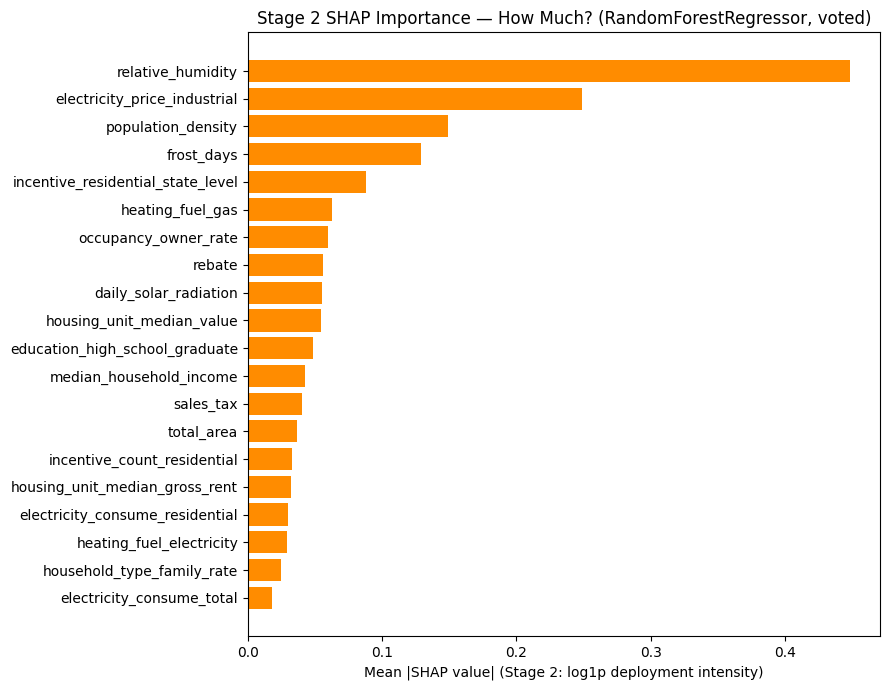

Saved to ../outputs/figures/transfer/03b_shap_stage2_bar_voted.png


In [11]:
top2 = stage2_importance.head(20).sort_values('mean_abs_shap')

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top2['feature'], top2['mean_abs_shap'], color='darkorange')
ax.set_xlabel('Mean |SHAP value| (Stage 2: log1p deployment intensity)')
ax.set_title(f'Stage 2 SHAP Importance — How Much? ({type(regressor).__name__}, {FEATURE_SET})')
plt.tight_layout()
fig_path = f'{FIGURE_DIR}/03b_shap_stage2_bar_{FEATURE_SET}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved to {fig_path}')

### Stage 2 SHAP Summary Plot

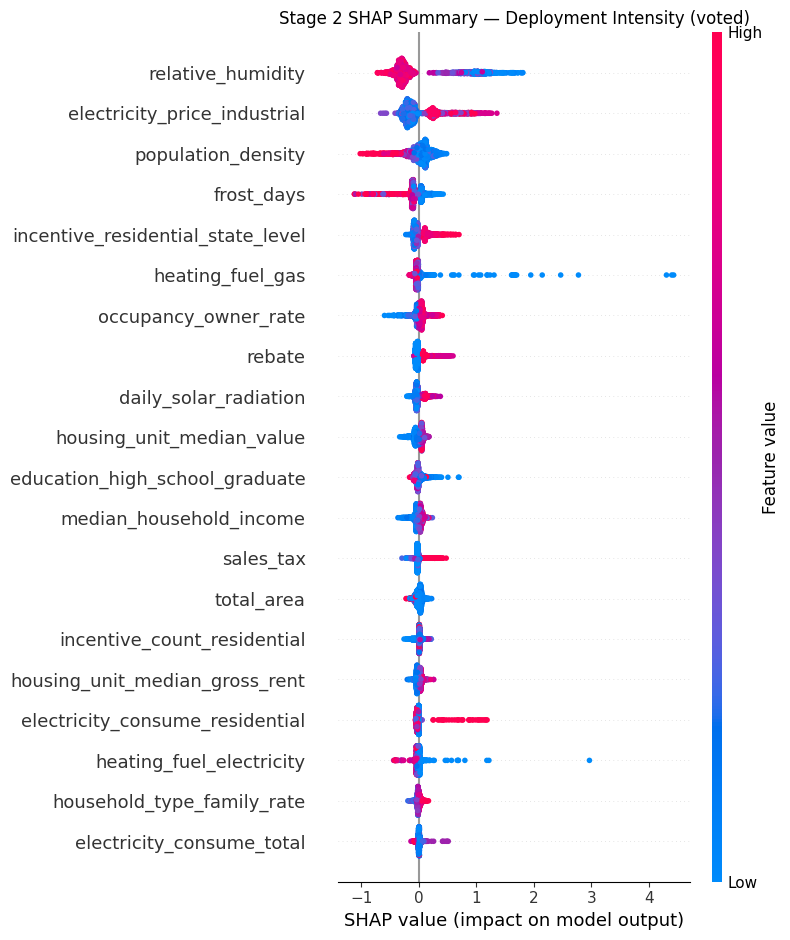

Saved to ../outputs/figures/transfer/03b_shap_stage2_summary_voted.png


In [12]:
plt.figure()
shap.summary_plot(shap_vals2, X_shap2, max_display=20, show=False)
plt.title(f'Stage 2 SHAP Summary — Deployment Intensity ({FEATURE_SET})')
plt.tight_layout()
fig_path = f'{FIGURE_DIR}/03b_shap_stage2_summary_{FEATURE_SET}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved to {fig_path}')

## Combined Importance: Stage 1 vs Stage 2

In [13]:
combined = stage1_importance.rename(columns={'mean_abs_shap': 'stage1_shap'}).merge(
    stage2_importance.rename(columns={'mean_abs_shap': 'stage2_shap'}),
    on='feature',
)
combined['rank_stage1'] = combined['stage1_shap'].rank(ascending=False).astype(int)
combined['rank_stage2'] = combined['stage2_shap'].rank(ascending=False).astype(int)
combined = combined.sort_values('stage1_shap', ascending=False)

save_path = f'{RESULT_DIR}/03b_shap_combined_importance_{FEATURE_SET}.csv'
combined.to_csv(save_path, index=False)

print(f'Saved to {save_path}')
print('Top 15 by Stage 1 importance:')
print(combined.head(15).to_string(index=False))

Saved to ../outputs/results/transfer/03b_shap_combined_importance_voted.csv
Top 15 by Stage 1 importance:
                       feature  stage1_shap  stage2_shap  rank_stage1  rank_stage2
                    total_area     0.035620     0.036418            1           14
            population_density     0.035534     0.148749            2            3
            education_bachelor     0.026777     0.006689            3           39
                    population     0.021142     0.008526            4           35
   heating_fuel_coal_coke_rate     0.019796     0.014441            5           26
         daily_solar_radiation     0.019124     0.055128            6            9
     housing_unit_median_value     0.014156     0.054226            7           10
             education_college     0.012940     0.012639            8           28
             relative_humidity     0.012154     0.448310            9            1
     electricity_consume_total     0.012043     0.017840        

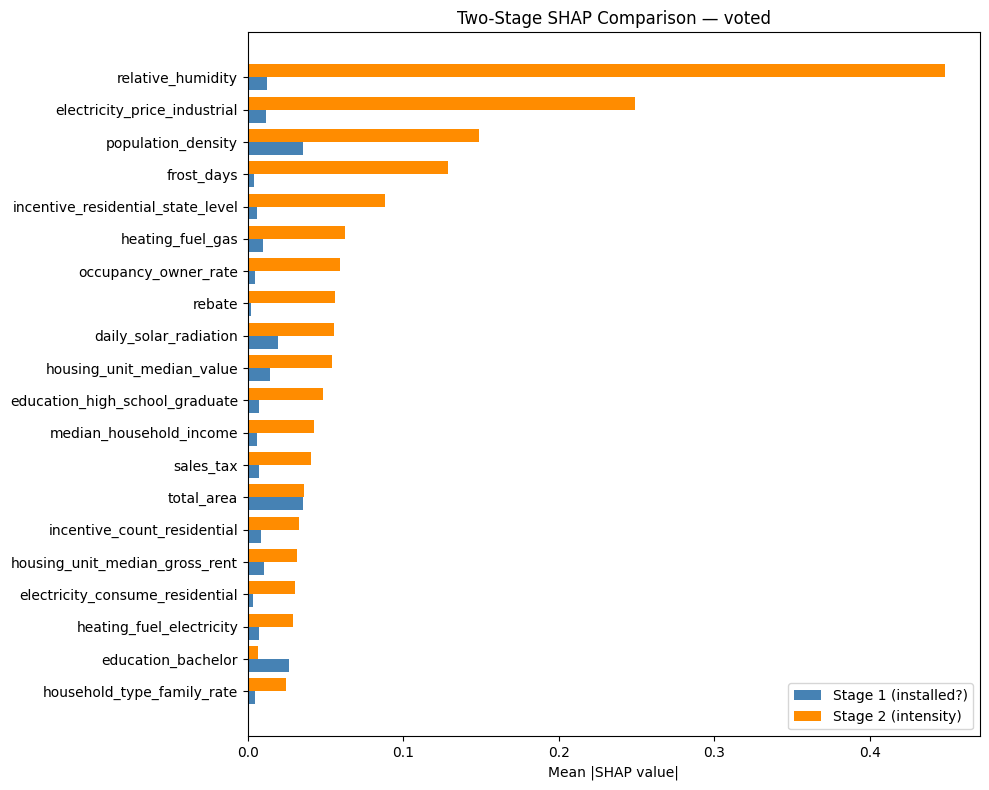

Saved to ../outputs/figures/transfer/03b_shap_twostage_combined_voted.png


In [14]:
top_n = 20
top_features = (
    combined.assign(max_shap=lambda d: d[['stage1_shap', 'stage2_shap']].max(axis=1))
    .nlargest(top_n, 'max_shap')
    .sort_values('max_shap')
)

y_pos = np.arange(len(top_features))
width = 0.4

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(y_pos - width / 2, top_features['stage1_shap'], width, label='Stage 1 (installed?)', color='steelblue')
ax.barh(y_pos + width / 2, top_features['stage2_shap'], width, label='Stage 2 (intensity)', color='darkorange')
ax.set_yticks(y_pos)
ax.set_yticklabels(top_features['feature'])
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'Two-Stage SHAP Comparison — {FEATURE_SET}')
ax.legend()
plt.tight_layout()
fig_path = f'{FIGURE_DIR}/03b_shap_twostage_combined_{FEATURE_SET}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved to {fig_path}')

## Interpretation Notes

**Stage 1 SHAP** (Has Solar?)
- Explains which features make a census tract more or less likely to have *any* solar installation.
- SHAP values are for the *installed* class (class 1).
- Positive SHAP → pushes prediction toward "has solar".

**Stage 2 SHAP** (Deployment Intensity)
- Only computed on *installed tracts* (tile_count > 0).
- The model predicts `log1p(deployment density per 1000 households)`.
- Positive SHAP → pushes prediction toward higher deployment density.
- Features that matter here reflect *how much* solar gets deployed, not just *whether* it exists.

**Key difference between stages**
- Stage 1 acts as an *adoption classifier*: driven by area scale, population density, and socioeconomic proxies.
- Stage 2 acts as an *intensity regressor*: driven more strongly by climate (humidity), electricity price, and energy-use patterns.
- Features with high importance in *both* stages are globally robust signals for solar deployment.

**SHAP values are model explanations, not causal effects.**  
For Taiwan transfer, Stage 1 scores answer: "Does this region resemble places in the US that adopted solar?"  
Stage 2 scores answer: "Among regions that look like adopters, how intense does deployment tend to be?"